In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

In [ ]:
from ratansunpy.client import RATANClient, ARClient
from ratansunpy.utils import get_project_root
import matplotlib.pyplot as plt
from astropy.io import fits
from ratansunpy.core.ar_handling import ARHandler
import random
import os
from ratansunpy.time import TimeRange

import warnings
warnings.filterwarnings("ignore")

In [3]:
processed_path = get_project_root()/"data"/"20170905_121217_sun+0_out_processed.fits"
raw_path = get_project_root()/"data"/"20170905_121217_sun+0_out.fits"
processed_hdul = fits.open(processed_path)
raw_hdul = fits.open(raw_path)

In [ ]:
ratan_client = RATANClient()
srs_table = ratan_client.form_srstable_with_time_shift(processed_hdul)

In [5]:
srs_table

Date,ID,Number,Carrington Longitude,Area,Z,Longitudinal Extent,Number of Sunspots,Mag Type,Latitude,Longitude,RatanTime
str10,str2,int64,int64,int64,str3,int64,int64,str16,float64,float64,str16
2017-09-05,I,2673,119,680,Dkc,7,28,Beta-Gamma-Delta,408.69101889567594,-98.01836659801228,2017/09/05 09:12
2017-09-05,I,2674,104,740,Fhi,18,34,Beta,47.36041326137899,143.00174423677404,2017/09/05 09:12
2017-09-05,I,2675,179,10,Bxo,5,4,Beta,900.4670848300949,309.2825831307679,2017/09/05 09:12
2017-09-05,I,2676,168,30,Cro,8,4,Beta,899.7829666555876,160.02607015230404,2017/09/05 09:12
2017-09-05,I,2677,52,10,Axx,1,2,Alpha,-683.2804279668718,-28.803008992661006,2017/09/05 09:12


In [ ]:
handler = ARHandler(processed_hdul)

In [7]:
ar_2673 = handler.extract_ar_data_with_window(latitude=408.69)
mask_2673 = handler.compute_ar_mask(ar_2673)

Text(0.5, 1.0, 'Mask value across FREQ')

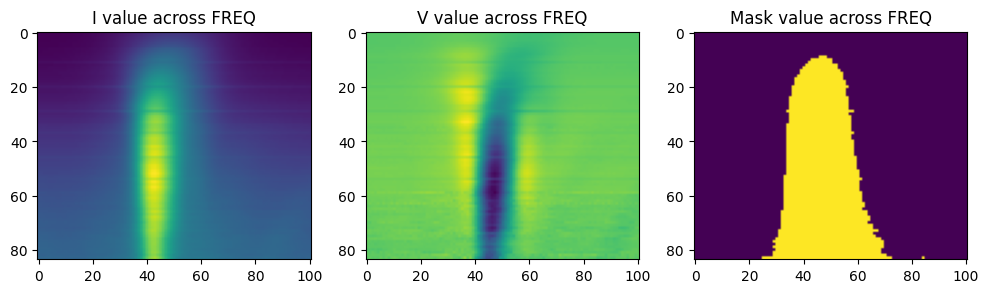

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(131); plt.imshow(ar_2673[0]); plt.title("I value across FREQ")
plt.subplot(132); plt.imshow(ar_2673[1]); plt.title("V value across FREQ")
plt.subplot(133); plt.imshow(mask_2673); plt.title("Mask value across FREQ")

In [9]:
ar_hdul, filename = handler.process_one_region(latitude=408.69, ar_number='2673')

In [10]:
for card in ar_hdul[0].header.cards:
    print(card)

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  101                                                  
NAXIS2  =                   84                                                  
NAXIS3  =                    3                                                  
EXTEND  =                    T                                                  
AR_NUM  = '2673    '                                                            
LATITUDE=               408.69                                                  
DATE-OBS= '2017/09/05'                                                          
TIME-OBS= '09:12:17.400'                                                        
CDELT1  =        2.97966442874                                                  
CRPIX   =          1604.5349

Text(0.5, 1.0, 'Mask value across FREQ')

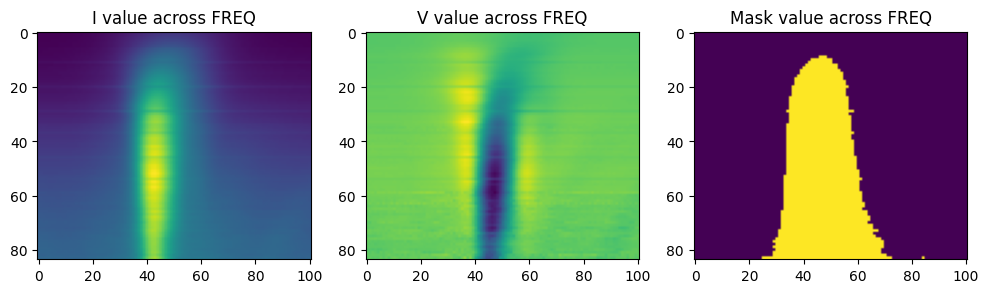

In [11]:
plt.figure(figsize=(12,5))
plt.subplot(131); plt.imshow(ar_hdul[0].data[0]); plt.title("I value across FREQ")
plt.subplot(132); plt.imshow(ar_hdul[0].data[1]); plt.title("V value across FREQ")
plt.subplot(133); plt.imshow(ar_hdul[0].data[2]); plt.title("Mask value across FREQ")

Text(0.5, 1.0, 'MEAN value across FREQ')

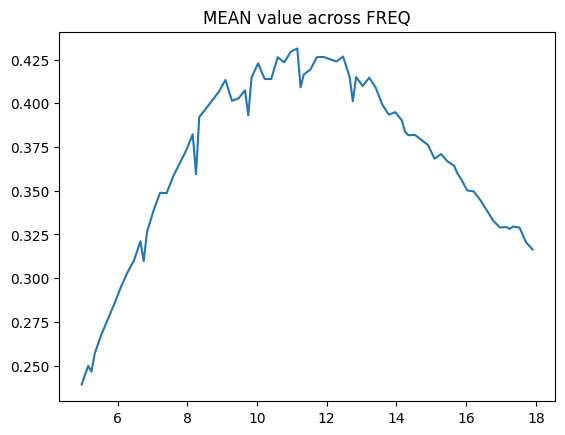

In [12]:
plt.plot(ar_hdul[6].data, ar_hdul[1].data); plt.title(f"{ar_hdul[1].name} value across {ar_hdul[6].name}")

In [13]:
save_path = get_project_root()/"data"
ar_data = handler.extract_ars_from_scan(save_path=save_path)
for _, filename, in ar_data:
    print(f"AR was extracted and save to {filename}")

AR was extracted and save to 20170905_091217_AR2673_0.0.fits
AR was extracted and save to 20170905_091217_AR2674_0.0.fits
AR was extracted and save to 20170905_091217_AR2675_0.0.fits
AR was extracted and save to 20170905_091217_AR2676_0.0.fits
AR was extracted and save to 20170905_091217_AR2677_0.0.fits


In [14]:
# download extracted AR (widnow size 50) from SAO server 
AR_TIMERANGE = TimeRange('2009-01-01', '2025-03-22')
AR = ["12192", "12371"]
AZIMUTH = ["0", "-2", "2"] 

ar_client = ARClient()
ar_urls = ar_client.acquire_data(timerange=AR_TIMERANGE, ar_nums=AR, azimuths=AZIMUTH)
print('AR URLS (random 5): ', *random.sample(ar_urls, 5), sep="\n")

local_ar_paths = ar_client.download_data(timerange=AR_TIMERANGE, ar_nums=AR, azimuths=AZIMUTH, 
                                         save_to=os.path.join(os.getcwd(), 'data', 'AR_data'))

AR URLS (random 5): 
http://spbf.sao.ru/data/solar_data/AR_data/2015/20150623_091545_AR2371_0.0.fits
http://spbf.sao.ru/data/solar_data/AR_data/2015/20150617_091427_AR2371_0.0.fits
http://spbf.sao.ru/data/solar_data/AR_data/2014/20141024_085751_AR2192_0.0.fits
http://spbf.sao.ru/data/solar_data/AR_data/2015/20150619_092336_AR2371_-2.0.fits
http://spbf.sao.ru/data/solar_data/AR_data/2015/20150625_090728_AR2371_2.0.fits
